# Customer Churn Prediction — Exploratory Data Analysis
**Project:** xFusionCorp MLOps Platform  
**Author:** Dineth Sasanka  
**Date:** 2026-05-28  

## Objective
Understand the Telco Customer Churn dataset before building our ML pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")


Libraries loaded successfully!
Pandas version: 3.0.3
Numpy version: 2.4.6


In [13]:
df = pd.read_csv('/home/mlops/MLOPS/data/raw/Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

#Display the last 10 rows of the dataset
#df.tail(10)

#Display the first 10 rows of the dataset
df.head(10)

Dataset shape: (7043, 21)
Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 1. Dataset Overview
Let's understand what columns we have and their data types.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] > 0])

Missing Values Summary:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


## 2. Target Variable — Churn
How many customers actually churned? This tells us if our dataset is balanced.

Churn Distribution:
No Churn : 5174  (73.5%)
Churned  : 1869 (26.5%)


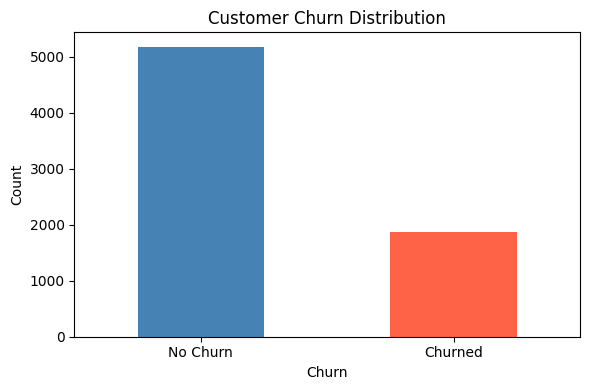

Chart saved!


In [17]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"No Churn : {churn_counts['No']}  ({churn_pct['No']:.1f}%)")
print(f"Churned  : {churn_counts['Yes']} ({churn_pct['Yes']:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Churn', 'Churned'], rotation=0)
plt.tight_layout()
plt.savefig('/home/mlops/MLOPS/notebooks/churn_distribution.png')
plt.show()
print("Chart saved!")

## 3. Numerical Features
Analyzing tenure, monthly charges, and total charges.

In [18]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# TotalCharges has a known issue — fix it first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Numerical Features Summary:")
df[numerical_cols].describe().round(2)

Numerical Features Summary:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


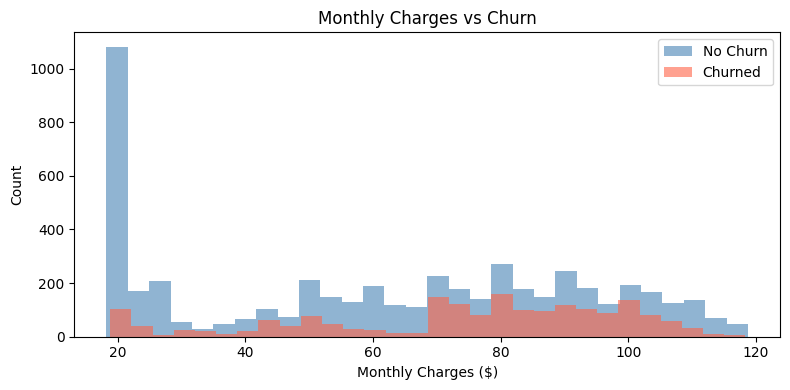

In [20]:
churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned = df[df['Churn'] == 'No']['MonthlyCharges']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(not_churned, bins=30, alpha=0.6, color='steelblue', label='No Churn')
ax.hist(churned, bins=30, alpha=0.6, color='tomato', label='Churned')
ax.set_title('Monthly Charges vs Churn')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('/home/mlops/MLOPS/notebooks/monthly_charges_vs_churn.png')
plt.show()

## 4. Key Findings

1. **Churn Rate** — ~26% of customers churned (imbalanced dataset)
2. **Monthly Charges** — Churned customers tend to have higher monthly charges
3. **TotalCharges** — Had whitespace issues, converted to numeric
4. **Next Steps** — Data preprocessing and feature engineering in next notebook

In [23]:
summary = {
    'total_customers': len(df),
    'churned_customers': int(churn_counts['Yes']),
    'churn_rate': round(float(churn_pct['Yes']), 2),
    'features': list(df.columns),
    'missing_values': missing_df[missing_df['Missing Values'] > 0].to_dict()
}

import json
with open('/home/mlops/MLOPS/data/processed/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("EDA summary saved to data/processed/eda_summary.json")

EDA summary saved to data/processed/eda_summary.json
